In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import itertools as it
import math
import scipy.stats as stats
import arviz as az
import seaborn as sns
from collections import Counter

In [2]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
sns.set_theme(palette="colorblind")

In [3]:
r = range(1, 7)
sample = [(i, j) for i in r for j in r]
print(sample)

[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]


In [4]:
len(sample)

36

In [5]:
sum(sample[0])

2

In [6]:
sum(sample[35])

12

In [7]:
z = [sum(point) for point in sample]
z

[2,
 3,
 4,
 5,
 6,
 7,
 3,
 4,
 5,
 6,
 7,
 8,
 4,
 5,
 6,
 7,
 8,
 9,
 5,
 6,
 7,
 8,
 9,
 10,
 6,
 7,
 8,
 9,
 10,
 11,
 7,
 8,
 9,
 10,
 11,
 12]

In [8]:
# Conteggio delle occorrenze di ciascun valore in z
frequencies = Counter(z)
# Ordinamento dei risultati in base al valore di z
sorted_frequencies = dict(sorted(frequencies.items()))
print(sorted_frequencies)

{2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 5, 9: 4, 10: 3, 11: 2, 12: 1}


In [9]:
# Calcolo delle proporzioni (probabilità)
total_outcomes = len(sample)
probabilities = {z_value: count / total_outcomes for z_value, count in sorted_frequencies.items()}

print(probabilities)

{2: 0.027777777777777776, 3: 0.05555555555555555, 4: 0.08333333333333333, 5: 0.1111111111111111, 6: 0.1388888888888889, 7: 0.16666666666666666, 8: 0.1388888888888889, 9: 0.1111111111111111, 10: 0.08333333333333333, 11: 0.05555555555555555, 12: 0.027777777777777776}


In [10]:
df = pd.DataFrame(list(probabilities.items()), columns=['z', 'Probability'])
print(df)

     z  Probability
0    2     0.027778
1    3     0.055556
2    4     0.083333
3    5     0.111111
4    6     0.138889
5    7     0.166667
6    8     0.138889
7    9     0.111111
8   10     0.083333
9   11     0.055556
10  12     0.027778


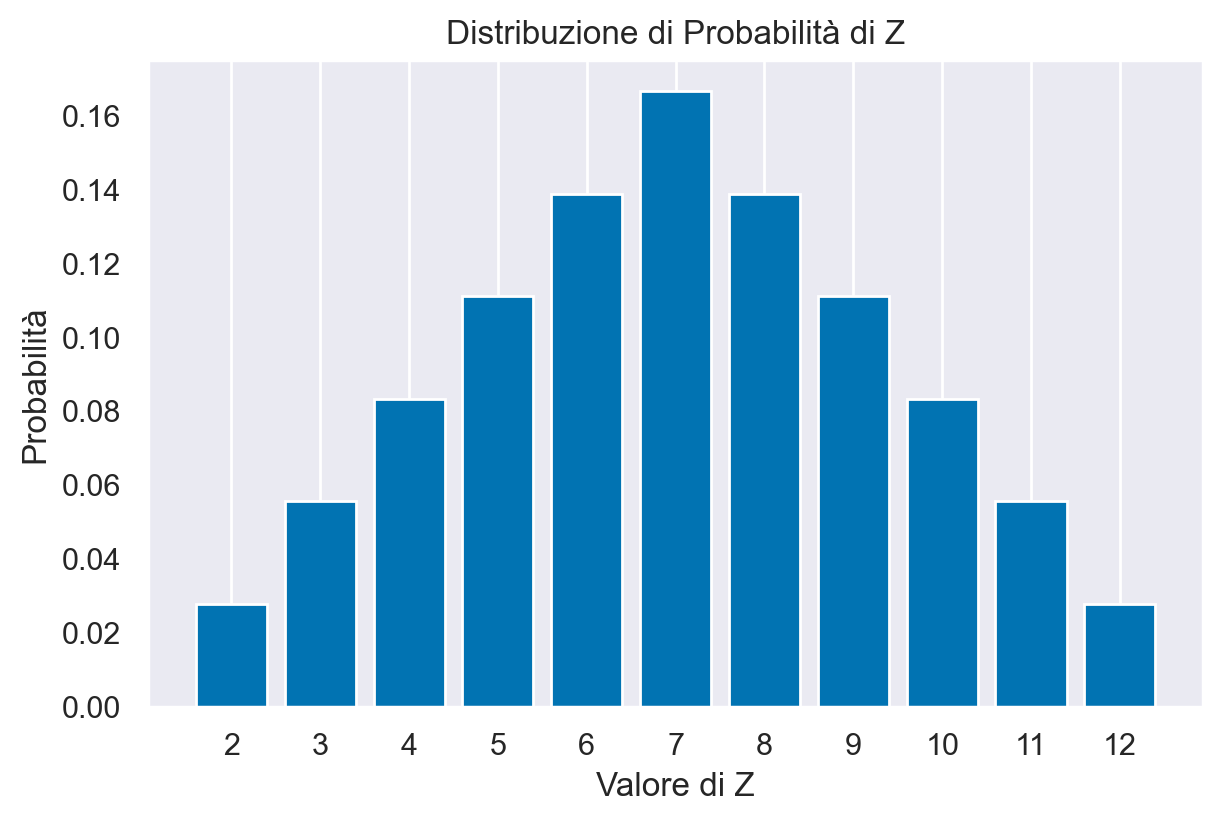

In [11]:
plt.figure(figsize=(6, 4))
plt.bar(df['z'], df['Probability'])
plt.xlabel('Valore di Z')
plt.ylabel('Probabilità')
plt.title('Distribuzione di Probabilità di Z')
plt.xticks(range(2, 13))  # Per mostrare tutte le etichette sull'asse x
plt.grid(axis='y')
plt.show()

In [12]:
def roll_die():
    """
    returns a random int between 1 and 6
    """
    return rng.choice([1, 2, 3, 4, 5, 6])

In [13]:
def roll_two_dice(n):
    """
    returns a random int between 2 and 12
    """
    rolls = []
    for i in range(n):
        two_dice = roll_die() + roll_die()
        rolls.append(two_dice)
    return rolls


In [14]:
nrolls = 100000
res = roll_two_dice(nrolls)
print(*res[1:50])

7 9 6 3 10 10 10 5 9 7 8 9 8 7 5 5 7 11 6 6 8 7 9 10 7 6 4 5 10 11 9 5 9 4 7 4 8 4 9 9 6 9 3 10 8 9 8 7 5


In [15]:
df = pd.DataFrame()
df["y"] = res 

In [16]:
abs_freqs = df["y"].value_counts().sort_index()
px = abs_freqs / nrolls
list(zip(list(range(2, 13)), px))

[(2, 0.0279),
 (3, 0.05467),
 (4, 0.083),
 (5, 0.11032),
 (6, 0.13932),
 (7, 0.16827),
 (8, 0.13834),
 (9, 0.11061),
 (10, 0.08499),
 (11, 0.05482),
 (12, 0.02776)]

In [17]:
def same_date(num_people, num_same):
    # initialize list from 0 to 365
    possible_dates = range(366)
    # list of zeros
    birthdays = [0] * 366
    # increments by 1 the days corresponding to to the randomly chosen
    # birthdays of num_people individuals
    for p in range(num_people):
        birth_date = rng.choice(possible_dates)
        birthdays[birth_date] += 1
    # True if at least one day records a number of birthdays >= num_same;
    # False otherwise
    return max(birthdays) >= num_same


def birthday_prob(num_people, num_same, num_trials):
    num_hits = 0
    # repeat the simulation num_trials times
    for t in range(num_trials):
        # if same_date() returns True, then increment num_hits by 1
        if same_date(num_people, num_same):
            num_hits += 1
    return num_hits / num_trials


for num_people in [10, 23, 30]:
    print(
        "For",
        num_people,
        "est. prob. of a shared birthday is",
        birthday_prob(num_people, 2, 10000),
    )
    numerator = math.factorial(366)
    denom = (366**num_people) * math.factorial(366 - num_people)
    print("Actual prob. for N = 100 =", 1 - numerator / denom)


For 10 est. prob. of a shared birthday is 0.1203
Actual prob. for N = 100 = 0.1166454118039999


For 23 est. prob. of a shared birthday is 0.5122
Actual prob. for N = 100 = 0.5063230118194599


For 30 est. prob. of a shared birthday is 0.707
Actual prob. for N = 100 = 0.7053034120089917


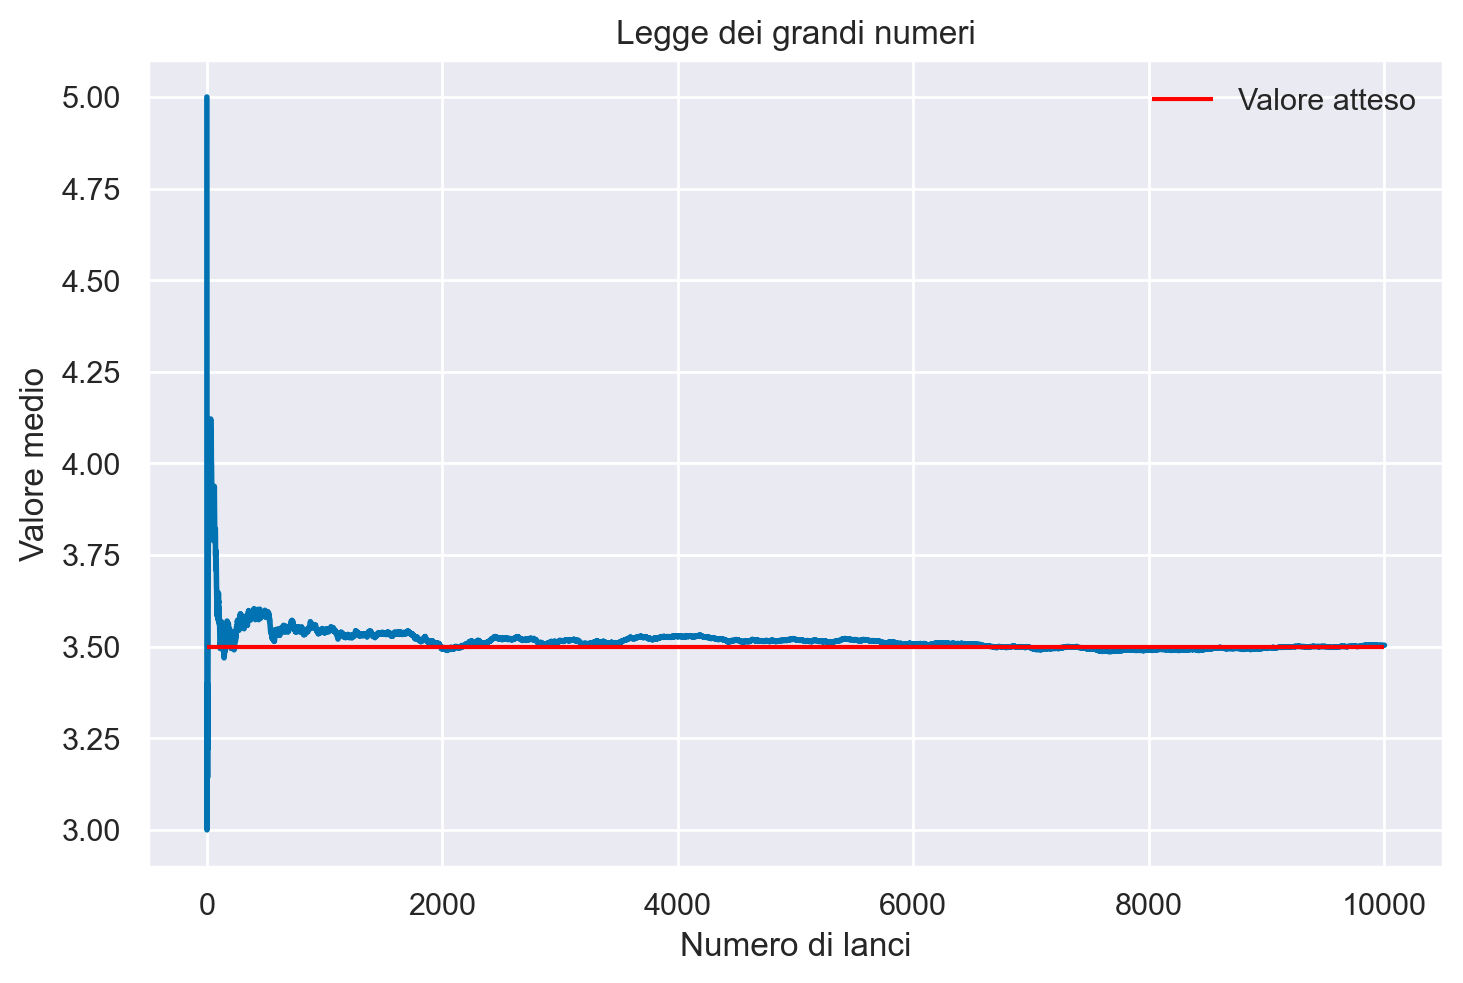

In [18]:
def simulate_dice_rolls(num_rolls):
    """Simulate dice rolls and return the average value for each roll."""
    total = 0
    averages = []
    for i in range(1, num_rolls + 1):
        roll = roll_die()
        total += roll
        averages.append(total / i)
    return averages


def plot_dice_rolls(averages, num_rolls):
    """
    Plot the average value after each dice roll.
    """
    x = range(1, num_rolls + 1)
    plt.plot(x, averages, linewidth=2)
    plt.hlines(y=3.5, xmin=0, xmax=num_rolls, color="red", label="Valore atteso")
    plt.xlabel("Numero di lanci")
    plt.ylabel("Valore medio")
    plt.title("Legge dei grandi numeri")
    plt.legend()
    plt.show()


if __name__ == "__main__":
    num_rolls = 10000
    averages = simulate_dice_rolls(num_rolls)
    plot_dice_rolls(averages, num_rolls)


In [19]:
def count_same_birthdays(birthday_list):
    same_birthdays = {}
    for name, birthday in birthday_list:
        if birthday in same_birthdays:
            same_birthdays[birthday].append(name)
        else:
            same_birthdays[birthday] = [name]

    return same_birthdays


# Example input with 5 students
birthday_list = [
    ("Mario Rossi", "agosto 3"),
    ("Giovanna Bianchi", "agosto 3"),
    ("Maria Neri", "agosto 3"),
    ("Francesco Ferrari", "giugno 12"),
    ("Alice Esposito", "maggio 26"),
    ("Giovanna Romano", "giugno 12"),
    ("Maria Gallo", "agosto 3"),
]

same_birthdays = count_same_birthdays(birthday_list)

# Print shared birthdays
for birthday, students in same_birthdays.items():
    if len(students) > 1:
        print(f"Compleanno {birthday}: {', '.join(students)}")

Compleanno agosto 3: Mario Rossi, Giovanna Bianchi, Maria Neri, Maria Gallo
Compleanno giugno 12: Francesco Ferrari, Giovanna Romano


In [20]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Tue Feb 06 2024

Python implementation: CPython
Python version       : 3.11.7
IPython version      : 8.19.0

numpy     : 1.26.2
scipy     : 1.11.4
seaborn   : 0.13.0
pandas    : 2.1.4
matplotlib: 3.8.2
arviz     : 0.17.0

Watermark: 2.4.3

